In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

<h2>Работа с данными</h2>

In [2]:
df = pd.read_csv('data/HeartFailureDataset.csv')
print(f'Размерность: {df.shape}')

df.head(10)


Размерность: (70000, 13)


,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,18393,2,168,62,110,80,1,1,0,0,1,0
1,1,20228,1,156,85,140,90,3,1,0,0,1,1
2,2,18857,1,165,64,130,70,3,1,0,0,0,1
3,3,17623,2,169,82,150,100,1,1,0,0,1,1
4,4,17474,1,156,56,100,60,1,1,0,0,0,0
5,8,21914,1,151,67,120,80,2,2,0,0,0,0
6,9,22113,1,157,93,130,80,3,1,0,0,1,0
7,12,22584,2,178,95,130,90,3,3,0,0,1,1
8,13,17668,1,158,71,110,70,1,1,0,0,1,0
9,14,19834,1,164,68,110,60,1,1,0,0,0,0


In [3]:
df["age"] = (df["age"] / 365).astype(int) # Меняем возраст с дней на годы
print('\n Кол-во пропусков в столбцах:')
df.isna().sum()


 Кол-во пропусков в столбцах:


id             0
age            0
gender         0
height         0
weight         0
ap_hi          0
ap_lo          0
cholesterol    0
gluc           0
smoke          0
alco           0
active         0
cardio         0
dtype: int64

In [4]:
print(f'Кол-во дубликатов: {df.duplicated().sum()}')

Кол-во дубликатов: 0


In [5]:
print('Типы данных:')
df.dtypes


Типы данных:


id             int64
age            int64
gender         int64
height         int64
weight         int64
ap_hi          int64
ap_lo          int64
cholesterol    int64
gluc           int64
smoke          int64
alco           int64
active         int64
cardio         int64
dtype: object

In [6]:
print('Распределение по гендерному признаку')
# 1 = Female, 2 = Male
df["gender"].map({1: "Женщина", 2: "Мужчина"}).value_counts()


Распределение по гендерному признаку


gender
Женщина    45530
Мужчина    24470
Name: count, dtype: int64

In [7]:
print('Распределение по курящим')
df["smoke"].map({0: "Не курящие", 1: "Курящие"}).value_counts()



Распределение по курящим


smoke
Не курящие    63831
Курящие        6169
Name: count, dtype: int64

In [8]:
print('Распределение по пьющим')
df["alco"].map({0: "Не пьющие", 1: "Пьющие"}).value_counts()

Распределение по пьющим


alco
Не пьющие    66236
Пьющие        3764
Name: count, dtype: int64

In [9]:
print('Распределение по активному образу жизни')
df["active"].map({0: "Не активные", 1: "Активные"}).value_counts()

Распределение по активному образу жизни


active
Активные       56261
Не активные    13739
Name: count, dtype: int64

In [10]:
print('Аномально низкий рост среди пациентов: ')

df[df['height'] <= 125]

Аномально низкий рост среди пациентов: 


,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
224,309,59,2,76,55,120,80,1,1,0,0,1,0
3420,4838,39,1,100,70,100,70,1,1,0,0,1,0
3735,5278,48,1,120,70,120,70,1,1,0,0,1,0
3752,5306,42,1,120,30,110,70,1,1,0,0,1,0
4212,5946,44,1,120,80,120,80,1,1,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
65302,93223,50,1,99,60,90,60,1,1,0,0,1,0
66023,94249,39,1,120,80,120,70,2,1,0,0,1,0
66479,94906,46,2,110,90,110,90,1,1,0,0,1,0
66643,95141,51,1,57,61,130,90,1,1,0,0,1,1


In [11]:
print('Аномально низкий вес среди пациентов: ')
df[df['weight'] < 40].value_counts().sum()



Аномально низкий вес среди пациентов: 


np.int64(52)

<h3>Введение нового параметра</h3>

In [12]:
print('И́ндекс ма́ссы те́ла (ИМТ, англ. body mass index (BMI)) — величина, \n позволяющая оценить степень соответствия массы человека и его роста и тем самым косвенно судить о том, \n является ли масса недостаточной, нормальной или избыточной. '
'Важен при определении показаний для необходимости лечения.')

df['BMI'] = df['weight'] / ((df['height'] / 100) ** 2).astype(int)

И́ндекс ма́ссы те́ла (ИМТ, англ. body mass index (BMI)) — величина, 
 позволяющая оценить степень соответствия массы человека и его роста и тем самым косвенно судить о том, 
 является ли масса недостаточной, нормальной или избыточной. Важен при определении показаний для необходимости лечения.


In [13]:
df.head(10)

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio,BMI
0,0,50,2,168,62,110,80,1,1,0,0,1,0,31.000000
1,1,55,1,156,85,140,90,3,1,0,0,1,1,42.500000
2,2,51,1,165,64,130,70,3,1,0,0,0,1,32.000000
3,3,48,2,169,82,150,100,1,1,0,0,1,1,41.000000
4,4,47,1,156,56,100,60,1,1,0,0,0,0,28.000000
5,8,60,1,151,67,120,80,2,2,0,0,0,0,33.500000
6,9,60,1,157,93,130,80,3,1,0,0,1,0,46.500000
7,12,61,2,178,95,130,90,3,3,0,0,1,1,31.666667
8,13,48,1,158,71,110,70,1,1,0,0,1,0,35.500000
9,14,54,1,164,68,110,60,1,1,0,0,0,0,34.000000


<h2>EDA</h2>

In [14]:
print('Информация о колонках: ')
print(df.info())

Информация о колонках: 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70000 entries, 0 to 69999
Data columns (total 14 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   id           70000 non-null  int64  
 1   age          70000 non-null  int64  
 2   gender       70000 non-null  int64  
 3   height       70000 non-null  int64  
 4   weight       70000 non-null  int64  
 5   ap_hi        70000 non-null  int64  
 6   ap_lo        70000 non-null  int64  
 7   cholesterol  70000 non-null  int64  
 8   gluc         70000 non-null  int64  
 9   smoke        70000 non-null  int64  
 10  alco         70000 non-null  int64  
 11  active       70000 non-null  int64  
 12  cardio       70000 non-null  int64  
 13  BMI          70000 non-null  float64
dtypes: float64(1), int64(13)
memory usage: 7.5 MB
None


In [15]:
print('Статистика: ')
print(df.describe())

Статистика: 
                 id           age        gender        height        weight  \
count  70000.000000  70000.000000  70000.000000  70000.000000  70000.000000   
mean   49972.419900     52.840671      1.349571    164.359229     74.205543   
std    28851.302323      6.766774      0.476838      8.210126     14.395829   
min        0.000000     29.000000      1.000000     55.000000     10.000000   
25%    25006.750000     48.000000      1.000000    159.000000     65.000000   
50%    50001.500000     53.000000      1.000000    165.000000     72.000000   
75%    74889.250000     58.000000      2.000000    170.000000     82.000000   
max    99999.000000     64.000000      2.000000    250.000000    200.000000   

              ap_hi         ap_lo   cholesterol          gluc         smoke  \
count  70000.000000  70000.000000  70000.000000  70000.000000  70000.000000   
mean     128.817714     96.630414      1.366871      1.226457      0.088129   
std      154.011381    188.472530     

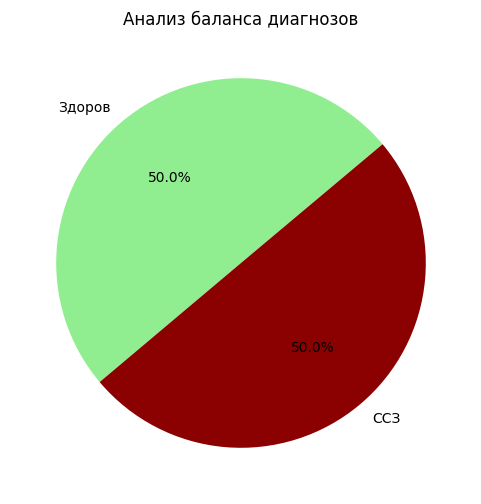

In [16]:
group_cardio = df['cardio'].value_counts()
labels = ['Здоров', 'ССЗ']
colors = ['lightgreen', 'darkred']
plt.figure(figsize=(6,6))
plt.pie(labels=labels, x=group_cardio.values, autopct='%1.1f%%', startangle=40, colors=colors)
plt.title('Анализ баланса диагнозов')
plt.savefig('graphs/pie_group_cardio.png')
plt.show()

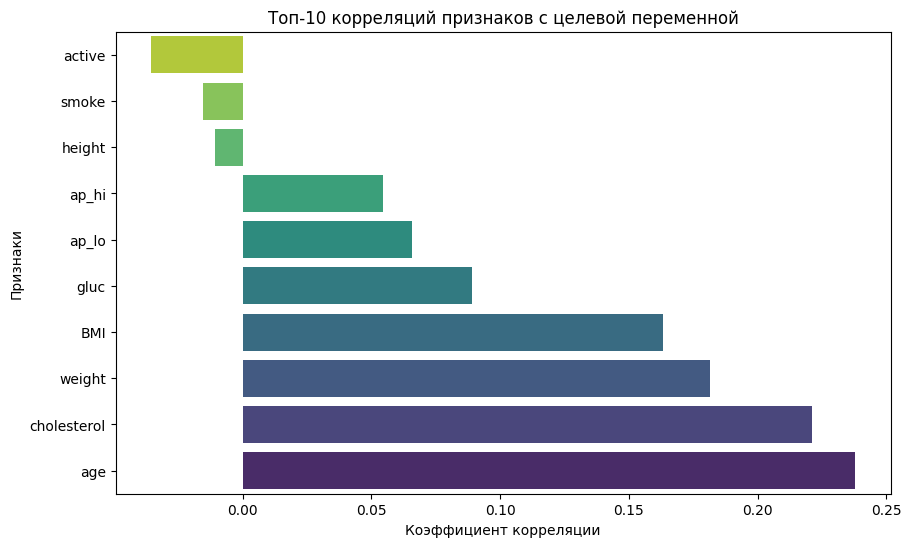

In [17]:
plt.figure(figsize=(10,6))
corr = df.corr(numeric_only=True)["cardio"].drop("cardio")
top_corr = corr.abs().sort_values(ascending=False).head(10)
top_corr_values = corr[top_corr.index]
top_corr_values = top_corr_values.sort_values()
sns.barplot(
    x=top_corr_values.values,
    y=top_corr_values.index,
    palette=sns.color_palette("viridis_r", len(top_corr_values))
)

plt.title("Топ-10 корреляций признаков с целевой переменной")
plt.xlabel("Коэффициент корреляции")
plt.ylabel("Признаки")
plt.savefig('graphs/top_10_correlations.png')
plt.show()